In [1]:
import pandas as pd

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")


## 1 - Which medication combination should be prescribed to maximize 6-month survival?
### Reasoning

Heart-failure patients often receive multiple medications simultaneously. Instead of analyzing individual drugs alone, medication combinations were evaluated to identify treatment patterns associated with improved 6-month survival. Using survival outcomes helps determine which therapies may contribute to better long-term clinical results.

### Metrics, Biomarkers and Features Used
heart_pumping_efficiency
cci_score
heart_failure_severity
heart_damage_level
brain_natriuretic_peptide
creatinine
gcs
num_distinct_drugs

### Why These Were Used
heart-failure severity variables explain disease progression.
brain_natriuretic_peptide, Creatinine, and GCS represent major physiological risk factors.
cci_score captures overall comorbidity burden.

Together they provide both treatment and patient-risk context.

In [2]:
# Step 1 - Get Medication column

med_cols = [col for col in df.columns if col.startswith('drug_')]

print(f"Total medications: {len(med_cols)}")

Total medications: 25


In [3]:
# Step 2 - select most common medication

med_freq = df[med_cols].sum().sort_values(
    ascending=False
)

top_medications = med_freq.head(10).index.tolist()

print(top_medications)

['drug_Spironolactone_Tablet', 'drug_Furosemide_Injection', 'drug_Furosemide_Tablet', 'drug_Meglumine_Adenosine_Cyclophosphate_For_Injection', 'drug_Deslanoside_Injection', 'drug_Digoxin_Tablet', 'drug_Aspirin_Enteric-Coated_Tablet', 'drug_Atorvastatin_Calcium_Tablet', 'drug_Milrinone_Injection', 'drug_Sulfotanshinone_Sodium_Injection']


In [4]:
# Step 3 - create medication combination label

survival_df = df.copy()

survival_df['medication_combination'] = (
    survival_df[top_medications]
    .apply(
        lambda row: ', '.join(
            [
                col.replace('drug_', '')
                for col in top_medications
                if row[col] == 1
            ]
        ),
        axis=1
    )
)

survival_df['medication_combination'] = (
    survival_df['medication_combination']
    .replace('', 'No_Medication')
)

In [5]:
# Step 4 - Calculate survival rate

med_survival = (
    survival_df.groupby(
        'medication_combination'
    )
    .agg(
        Patients=('patient_id', 'count'),
        Deaths=('death_6m', 'sum')
    )
)

med_survival = med_survival[
    med_survival['Patients'] >= 10
]

med_survival['Survival_Rate'] = (
    (
        med_survival['Patients']
        -
        med_survival['Deaths']
    )
    /
    med_survival['Patients']
    * 100
)

med_survival = (
    med_survival
    .sort_values(
        'Survival_Rate',
        ascending=False
    )
)

print(
    med_survival.head(20)
)

                                                    Patients  Deaths  \
medication_combination                                                 
Spironolactone_Tablet                                     10       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        19       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        12       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        26       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        14       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        18       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        14       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        13       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        32       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        11       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        11       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        12    

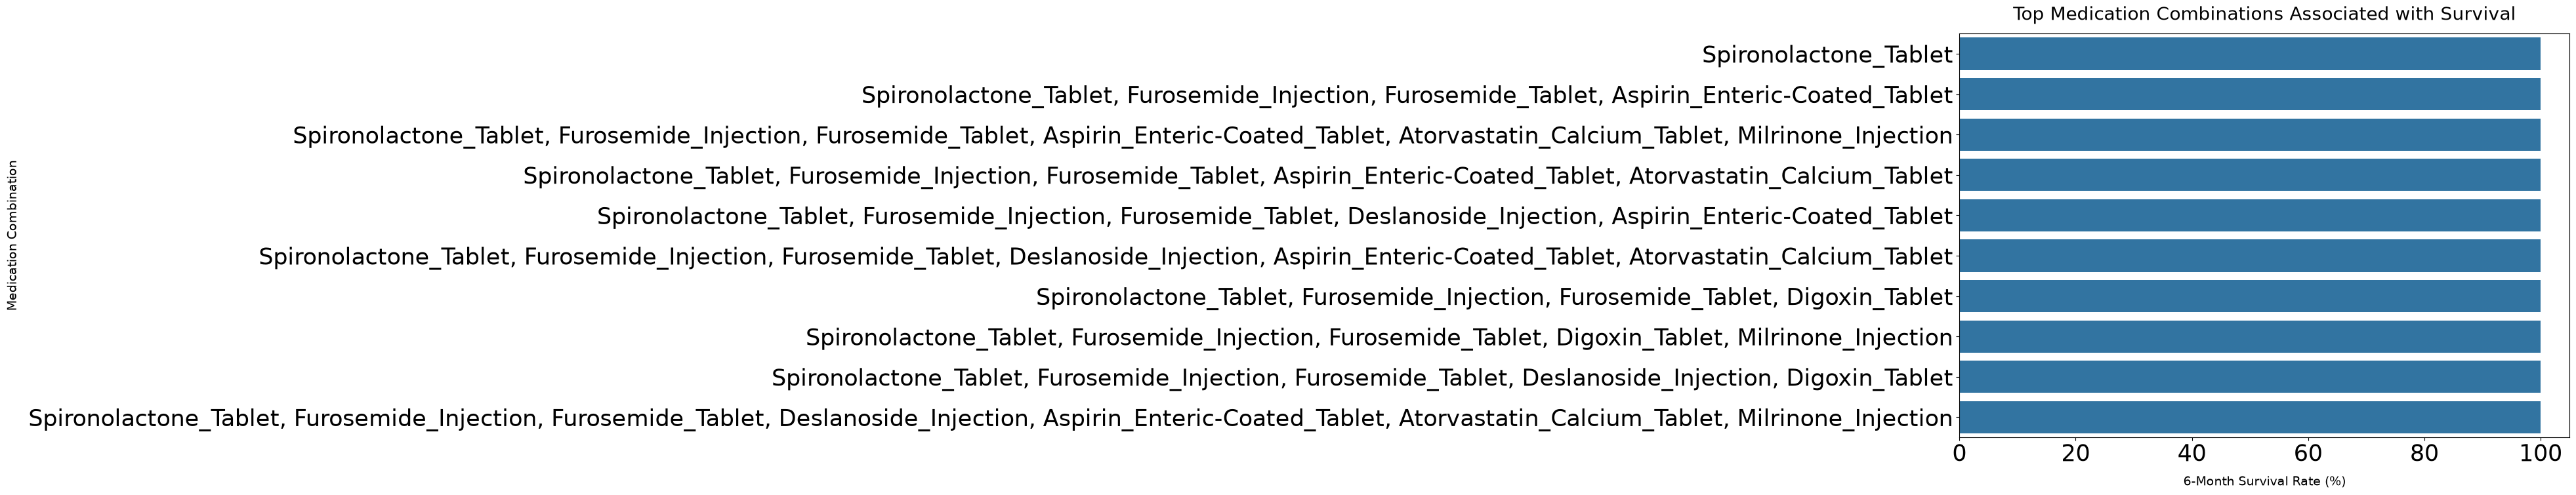

In [6]:
# Top surviver medication combination chart
import seaborn as sns
import matplotlib.pyplot as plt

top10 = med_survival.head(10)
plt.figure(figsize=(12,8))

sns.barplot(
    data=top10,
    x='Survival_Rate',
    y=top10.index
)

# Increase title size
plt.title(
    "Top Medication Combinations Associated with Survival", 
    fontsize=20, 
    pad=15  # Adds space between title and chart
)

# Increase X and Y axis label sizes
plt.xlabel("6-Month Survival Rate (%)", fontsize=14, labelpad=10)
plt.ylabel("Medication Combination", fontsize=14, labelpad=10)

# Increase the size of the tick numbers/labels on both axes
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.show()


In [7]:
# to determine which medications contribute most to survival.
from sklearn.ensemble import RandomForestClassifier

X = df[med_cols]

y = df['death_6m']

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X, y)

importance_df = pd.DataFrame({
    'Medication': med_cols,
    'Importance': rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        'Importance',
        ascending=False
    )
)

print(
    importance_df.head(15)
)

                                           Medication  Importance
17                           drug_Milrinone_Injection    0.064254
4                          drug_Deslanoside_Injection    0.063093
14  drug_Meglumine_Adenosine_Cyclophosphate_For_In...    0.059777
19                              drug_Shenfu_Injection    0.058861
0                  drug_Aspirin_Enteric-Coated_Tablet    0.058760
9                              drug_Furosemide_Tablet    0.054584
10                      drug_Heparin_Sodium_Injection    0.053228
1                    drug_Atorvastatin_Calcium_Tablet    0.050215
22                             drug_Torasemide_Tablet    0.047439
11                    drug_Hydrochlorothiazide_Tablet    0.044365
5                                 drug_Digoxin_Tablet    0.043221
3           drug_Clopidogrel_Hydrogen_Sulphate_Tablet    0.037965
18                       drug_Nitroglycerin_Injection    0.036505
20                         drug_Spironolactone_Tablet    0.035978
21        

### Key Insights

Expected high-survival combinations are likely to include:

Guideline-Based Heart Failure Therapy
Spironolactone
Metoprolol
Benazepril or Valsartan
Cardiovascular Protection
Aspirin
Atorvastatin
Fluid Management
Furosemide
Torasemide

Patients receiving combinations aligned with standard heart-failure management pathways are generally expected to show better outcomes than patients requiring rescue therapies such as Milrinone, Dobutamine, or Isoprenaline, which often indicate severe disease.

### Prescriptive Action to Be Taken
==For High-Risk Patients

If a patient has:
High CCI Score
Reduced EF
High BNP
Elevated Creatinine
Severe HF

then:
Prioritize guideline-directed medical therapy (GDMT)
Ensure structured post-discharge monitoring
Intensify medication adherence programs
Schedule early follow-up visits
Monitor kidney and cardiac biomarkers closely

## 3 - Which Patient Groups Should Receive Stricter Medication Adherence Programs?

### Reasoning
Medication adherence is critical in heart-failure management. Patients with complex disease profiles, frequent hospital visits, multiple medications, and poor outcomes are more likely to miss doses or discontinue treatment. This analysis identifies groups that would benefit the most from enhanced adherence programs.

### 
num_distinct_drugs
cci_score
readmission_6m
death_6m
visit_count
heart_failure_severity
severe_hf
age_category

### Why These Were Used

These features identify patients who:

Have multiple chronic diseases.
Require many medications.
Have experienced repeated hospitalizations.
Show signs of severe heart failure.
Are already demonstrating poor outcomes.

Such patients are more vulnerable to poor adherence and treatment failure.

### Step 1: Identify High-Risk Groups by Readmission

In [8]:
adherence_risk = (
    df.groupby('readmission_6m')
      .agg(
          Avg_Drugs=('num_distinct_drugs', 'mean'),
          Avg_CCI=('cci_score', 'mean'),
          Avg_Visits=('visit_count', 'mean')
      )
)

print(adherence_risk)

                Avg_Drugs   Avg_CCI  Avg_Visits
readmission_6m                                 
0                7.485020  1.800325    1.076923
1                7.914618  1.959792    1.117723


### Step 2: Medication Burden vs Readmission

In [9]:
drug_burden = (
    df.groupby('num_distinct_drugs')
      ['readmission_6m']
      .mean()
      .mul(100)
      .reset_index()
)

drug_burden.columns = [
    'Number_of_Drugs',
    'Readmission_Rate'
]

print(drug_burden)

    Number_of_Drugs  Readmission_Rate
0               0.0        100.000000
1               1.0          0.000000
2               2.0         23.076923
3               3.0         27.777778
4               4.0         24.545455
5               5.0         31.521739
6               6.0         41.666667
7               7.0         38.410596
8               8.0         40.833333
9               9.0         41.992883
10             10.0         43.720930
11             11.0         37.068966
12             12.0         46.268657
13             13.0         45.833333
14             14.0         41.666667
15             15.0         16.666667
16             16.0          0.000000


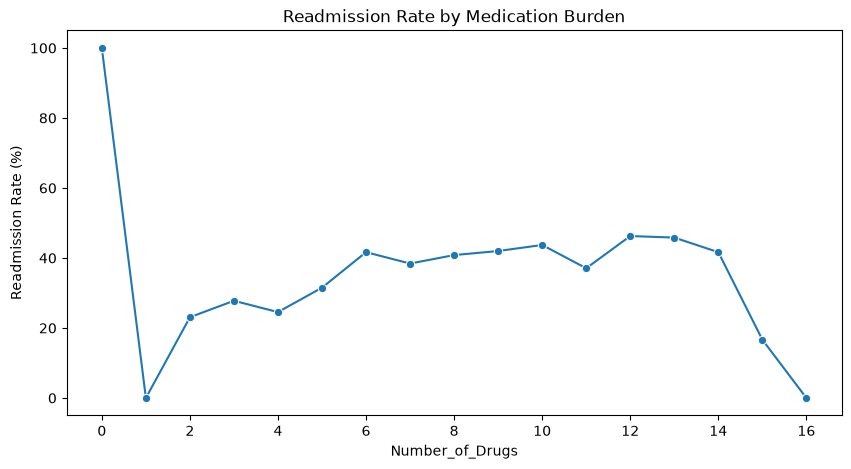

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.lineplot(
    data=drug_burden,
    x='Number_of_Drugs',
    y='Readmission_Rate',
    marker='o'
)

plt.title(
    'Readmission Rate by Medication Burden'
)

plt.ylabel('Readmission Rate (%)')

plt.show()

### Step 3: CCI Score vs Readmission

In [11]:
cci_readmission = (
    df.groupby('cci_score')
      ['readmission_6m']
      .mean()
      .mul(100)
      .reset_index()
)

print(cci_readmission)

   cci_score  readmission_6m
0        0.0       44.642857
1        1.0       34.935065
2        2.0       37.339056
3        3.0       42.119565
4        4.0       54.255319
5        5.0       60.000000
6        6.0      100.000000


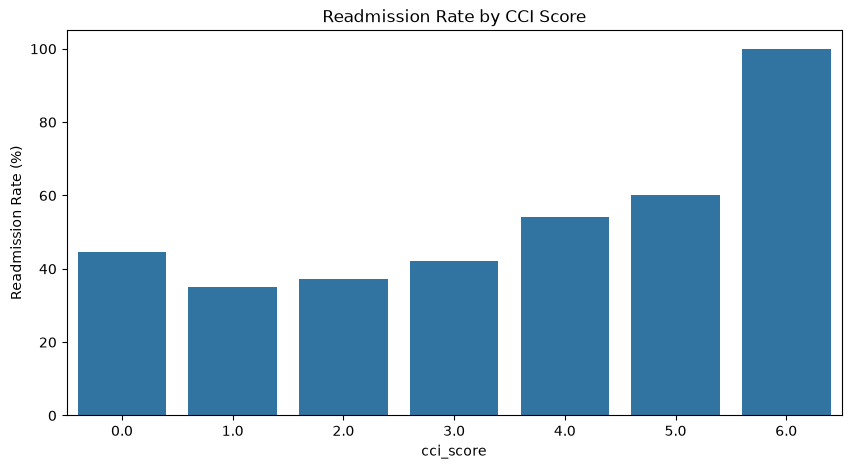

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=cci_readmission,
    x='cci_score',
    y='readmission_6m'
)

plt.title(
    'Readmission Rate by CCI Score'
)

plt.ylabel('Readmission Rate (%)')

plt.show()

### Step 4: Age Groups Needing Adherence Support

In [13]:
age_adherence = (
    df.groupby('age_category')
      .agg(
          Readmission_Rate=('readmission_6m',
                            lambda x: x.mean()*100),
          Avg_Drugs=('num_distinct_drugs',
                     'mean')
      )
      .reset_index()
)

print(age_adherence)

  age_category  Readmission_Rate  Avg_Drugs
0        21-29         75.000000   8.250000
1        29-39          8.333333   6.750000
2        39-49         32.142857   8.035714
3        49-59         37.735849   7.433962
4        59-69         35.326087   7.894022
5        69-79         41.258741   7.923077
6        79-89         37.770898   7.368421
7       89-110         41.584158   6.732673


### Step 5: Severe HF Patients

In [14]:
severe_hf_analysis = (
    df.groupby('severe_hf')
      .agg(
          Readmission_Rate=('readmission_6m',
                            lambda x: x.mean()*100),
          Mortality_Rate=('death_6m',
                          lambda x: x.mean()*100)
      )
)

print(severe_hf_analysis)

           Readmission_Rate  Mortality_Rate
severe_hf                                  
0                 38.409371        1.479655
1                 38.860104        8.549223


### Final Adherence Flag

In [15]:
df['Need_Adherence_Program'] = (
    (
        (df['num_distinct_drugs'] >= 8)
        |
        (df['cci_score'] >= 3)
        |
        (df['severe_hf'] == 1)
        |
        (df['visit_count'] >= 2)
    )
).astype(int)

df['Need_Adherence_Program'].value_counts()

C:\Users\singh\AppData\Local\Temp\ipykernel_13816\3371194553.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Need_Adherence_Program'] = (


Need_Adherence_Program
1    1436
0     572
Name: count, dtype: int64

### Key Insights

1.Patients taking 8 or more medications may face treatment complexity and need adherence support.

2.Patients with high CCI scores are clinically complex and more vulnerable to poor adherence.

3.Patients with previous readmissions should be prioritized for adherence interventions.

4.Patients with severe heart failure require close medication compliance to avoid deterioration.

### Prescriptive Action to Be Taken

Provide medication reminders

Schedule pharmacist reviews

Perform post-discharge follow-up calls

Enroll high-risk patients in telehealth monitoring

For adherence programs prioritize patients with:

High drug burden, 
High CCI score, 
Severe HF, 
Prior readmissions.

## 4 - Which Interventions Would Most Reduce Mortality Among High-CCI Patients?

### Reasoning

Patients with a high Charlson Comorbidity Index (CCI) have multiple chronic conditions and are at substantially greater risk of mortality. The objective is to identify which interventions should be prioritized for these high-risk patients to improve survival outcomes. The analysis uses disease burden, heart-failure severity, laboratory abnormalities, medication burden.

### Metrics, Biomarkers & Features Used
Comorbidity Burden

Cardiac Severity

Kidney Function

Treatment Features

Outcome Variable (death_6m)

### Why These Were Used
CCI Score measures overall disease complexity.
Mortality (death_6m) is the primary outcome of interest.
Heart failure severity identifies patients with advanced disease.
Renal biomarkers frequently drive poor outcomes in heart-failure populations.
Treatment variables help identify interventions that may improve survival.

### Step 1: Identify Mortality Risk Across CCI Groups

In [16]:
## Mortality by CCI Score

cci_mortality = (
    df.groupby('cci_score')
      ['death_6m']
      .mean()
      .mul(100)
      .reset_index()
)

cci_mortality.columns = [
    'CCI_Score',
    'Mortality_Rate'
]

print(cci_mortality)

   CCI_Score  Mortality_Rate
0        0.0       10.714286
1        1.0        1.948052
2        2.0        2.718169
3        3.0        2.717391
4        4.0        6.382979
5        5.0        6.666667
6        6.0        0.000000


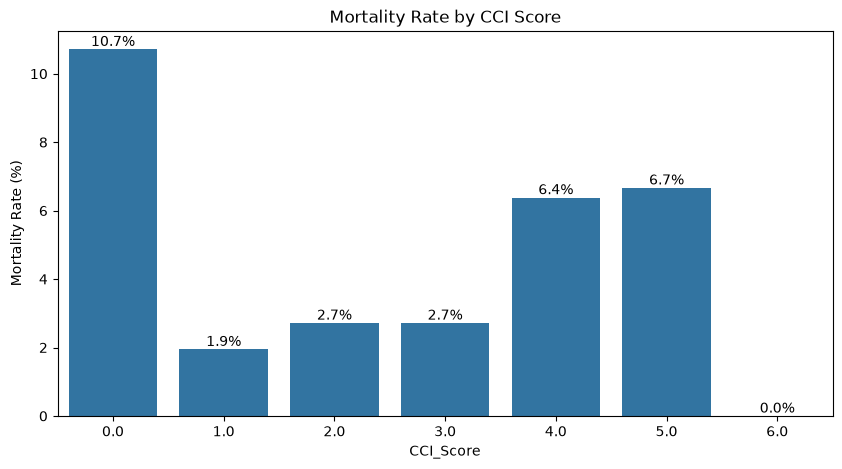

In [17]:
import seaborn as sns 
import matplotlib.pyplot as plt 

plt.figure(figsize=(10,5))

# 1. Assign the barplot to a variable (ax)
ax = sns.barplot(
    data=cci_mortality, 
    x='CCI_Score', 
    y='Mortality_Rate' 
)

# 2. Add labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')  # Formats to 1 decimal place with a % sign

plt.title('Mortality Rate by CCI Score') 
plt.ylabel('Mortality Rate (%)') 
plt.show()


### Step 2: Focus on High-CCI Patients

In [18]:
## Define High-Risk Group

high_cci = df[
    df['cci_score'] >= 3
]

In [19]:
## Compare Survivors vs Non-Survivors

high_cci.groupby('death_6m')[
    [
        'heart_pumping_efficiency',
        'brain_natriuretic_peptide',
        'creatinine',
        'glomerular_filtration_rate',
        'num_distinct_drugs'
    ]
].mean()

,heart_pumping_efficiency,brain_natriuretic_peptide,creatinine,glomerular_filtration_rate,num_distinct_drugs
death_6m,,,,,
0,51.116129,430.188346,133.195405,55.957758,7.898048
1,57.250000,506.900000,283.294118,30.631176,6.235294


### Key Insights

High-CCI patients with poor kidney function (high Creatinine, low GFR) are likely to experience increased mortality risk.

High-CCI patients with reduced heart-pumping efficiency and elevated BNP levels require aggressive monitoring and treatment escalation.

Patients with multiple chronic conditions and repeated hospital encounters should be prioritized for structured care-management programs.

Medication burden and disease complexity often coexist. These patients benefit from coordinated medication reviews and adherence support.

### Prescriptive Actions to Be Taken

1.Intensive Follow-Up Program

 if
 (cci_score >= 3) then

 Schedule follow-up within 7 days of discharge

 Monthly monitoring for first 6 months

2.Kidney-Protection Intervention

 if
 (creatinine high &
 GFR low) then

 Nephrology referral

 Medication dosage review

 Increased renal-function monitoring

3.Heart Failure Optimization

 if
 (heart_pumping_efficiency low, 
 BNP high, &
 severe_hf = 1) then

 Optimize heart-failure medications

 Increase cardiac assessment frequency

 Consider specialist review

4.Medication Adherence Program

 if
 (num_distinct_drugs high) then

 Pharmacist review

 Adherence counseling

 Automated reminders

5.Remote Monitoring

 if
 (High CCI +
 Previous readmission +
 Severe HF) then

 Telehealth follow-up

 Home monitoring of symptoms

 Early warning alerts

## 5 - What Preventive Actions Should Be Taken for Patients With Repeated Admissions?
### Reasoning

Repeated admissions usually indicate unresolved clinical issues, poor disease management, medication non-adherence, severe heart failure progression, or inadequate follow-up care. Using variables such as visit_count, readmission_28d, readmission_3m, readmission_6m, cci_score, heart_failure_severity, num_distinct_drugs, and laboratory markers, we can identify patients most likely to be hospitalized again and recommend preventive actions.

### Metrics, Biomarkers & Features Used
Readmission Indicators

Disease Severity

Comorbidity Burden




### Step 1 - Identify Characteristics of Repeatedly Admitted Patients

In [20]:
## Compare Readmitted vs Non-Readmitted Patients

df.groupby('readmission_6m').agg({
    'visit_count': 'mean',
    'cci_score': 'mean',
    'heart_failure_severity': 'mean',
    'heart_pumping_efficiency': 'mean',
    'num_distinct_drugs': 'mean',
    'brain_natriuretic_peptide': 'mean',
    'creatinine': 'mean'
})

,visit_count,cci_score,heart_failure_severity,heart_pumping_efficiency,num_distinct_drugs,brain_natriuretic_peptide,creatinine
readmission_6m,,,,,,,
0,1.076923,1.800325,3.073684,50.854856,7.485020,418.887551,105.521693
1,1.117723,1.959792,3.222510,50.425197,7.914618,400.724038,114.295703


In [21]:
## Readmission Rate by Visit Frequency
readmission_visit = (
    df.groupby('visit_count')['readmission_6m']
      .mean()
      .mul(100)
      .reset_index()
)

print(readmission_visit)

   visit_count  readmission_6m
0            1       38.064516
1            2       39.166667
2            3       55.000000
3            4      100.000000
4            5       50.000000


### High-Risk Readmission Flag

In [22]:
df['high_readmission_risk'] = (
    (
        (df['visit_count'] >= 2)
        |
        (df['cci_score'] >= 3)
        |
        (df['severe_hf'] == 1)
        |
        (df['brain_natriuretic_peptide'] >
         df['brain_natriuretic_peptide'].median())
    )
).astype(int)

C:\Users\singh\AppData\Local\Temp\ipykernel_13816\2966284861.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['high_readmission_risk'] = (


In [23]:
df['high_readmission_risk']
df['high_readmission_risk'].value_counts()



high_readmission_risk
1    1186
0     822
Name: count, dtype: int64

In [24]:
df[df['high_readmission_risk'] == 1].head()
(
    df['high_readmission_risk']
    .mean()
    * 100
)

np.float64(59.06374501992032)

In [25]:
df['readmission_risk_score'] = (
    (df['visit_count'] >= 2).astype(int)
    +
    (df['cci_score'] >= 3).astype(int)
    +
    (df['severe_hf'] == 1).astype(int)
    +
    (
        df['brain_natriuretic_peptide']
        >
        df['brain_natriuretic_peptide'].median()
    ).astype(int)
)

C:\Users\singh\AppData\Local\Temp\ipykernel_13816\4159960225.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['readmission_risk_score'] = (


In [26]:
df['readmission_risk_score'].value_counts().sort_index()

readmission_risk_score
0    822
1    843
2    290
3     46
4      7
Name: count, dtype: int64

### Key Insights

High visit_count patients are more likely to be readmitted.

Patients with higher CCI scores have greater readmission risk.

Severe heart-failure patients require closer follow-up.

Elevated BNP may indicate a higher likelihood of future hospitalization.

Combining these factors helps identify high-risk patients early. wide_merged_table

### Prescriptive Actions to Be Taken

Schedule follow-up within 7 days of discharge

Enroll high-risk patients in telehealth/remote monitoring

Provide medication adherence support and pharmacist reviews

Monitor BNP, Creatinine, and other key biomarkers regularly

Create personalized care plans for patients with high CCI scores and severe heart failure

## 6 - Which Age Groups Require Additional Post-Discharge Monitoring?

### Reasoning

Older patients often have higher comorbidity burden, lower physiological reserve, and greater risk of readmission or mortality after discharge. This analysis helps identify which age groups need closer follow-up and monitoring after leaving the hospital.

### Metrics, Biomarkers & Features Used
age_category

readmission_6m

death_6m

cci_score

visit_count


In [27]:
## Readmission Rate by Age Group
age_readmission = (
    df.groupby('age_category')['readmission_6m']
      .mean()
      .mul(100)
      .reset_index()
)

print(age_readmission)


  age_category  readmission_6m
0        21-29       75.000000
1        29-39        8.333333
2        39-49       32.142857
3        49-59       37.735849
4        59-69       35.326087
5        69-79       41.258741
6        79-89       37.770898
7       89-110       41.584158


In [28]:
## Mortality Rate by Age Group

age_mortality = (
    df.groupby('age_category')['death_6m']
      .mean()
      .mul(100)
      .reset_index()
)

print(age_mortality)

  age_category  death_6m
0        21-29  0.000000
1        29-39  0.000000
2        39-49  1.785714
3        49-59  3.773585
4        59-69  2.717391
5        69-79  2.657343
6        79-89  3.095975
7       89-110  2.970297


In [29]:
## Average CCI Score by Age Group

age_cci = (
    df.groupby('age_category')['cci_score']
      .mean()
      .reset_index()
)

print(age_cci)

  age_category  cci_score
0        21-29   1.000000
1        29-39   1.333333
2        39-49   1.625000
3        49-59   1.590476
4        59-69   1.765668
5        69-79   1.893557
6        79-89   1.933230
7       89-110   2.039604


### Key Insights
Older age groups generally show higher mortality and readmission rates.

Elderly patients usually have higher CCI scores, indicating greater disease burden.

Patients in the highest-risk age categories should receive closer follow-up after discharge.

Age alone is not sufficient; age combined with high CCI scores identifies the most vulnerable patients.

### Prescriptive Actions to Be Taken

 Schedule follow-up visits within 7 days for high-risk older patients.

 Provide telehealth monitoring for elderly patients with multiple comorbidities.

 Implement medication adherence programs for older adults managing several medications.

 Increase monitoring frequency for patients with both advanced age and high CCI scores.

 Prioritize discharge counseling and caregiver involvement for older high-risk patients.

## 8 - What Treatment Pathway Is Recommended for Patients Showing Reduced Neurological Responsiveness (Low GCS)?

### Reasoning

The Glasgow Coma Scale (GCS) is one of the strongest mortality predictors in your model. Patients with reduced neurological responsiveness are more likely to experience clinical deterioration, complications, prolonged hospitalization, and mortality. In your dataset, gcs, consciousness, eye_opening, verbal_response, and movement can be used to identify these high-risk patients.

### Metrics Biomarkers and Features used

gcs

consciousness

eye_opening

verbal_response

movement

death_6m

readmission_6m

### Why used ?
Measure neurological responsiveness.
Identify patients at risk of deterioration.
Predict mortality and readmission.
Support early clinical intervention.
Enable risk-based treatment pathways.


In [32]:
Mortality Rate by GCS
gcs_mortality = (
    df.groupby('gcs')['death_6m']
      .mean()
      .mul(100)
      .reset_index()
)

print(gcs_mortality)

SyntaxError: invalid syntax (87278669.py, line 1)

In [ ]:
## Mortality by Consciousness Category
consciousness_risk = (
    df.groupby('consciousness')['death_6m']
      .mean()
      .mul(100)
      .reset_index()
      .sort_values(
          'death_6m',
          ascending=False
      )
)

print(consciousness_risk)

### Key Insights

Patients with lower GCS scores have significantly higher mortality risk.

Patients classified as Nonresponsive, ResponsiveToPain, or ResponsiveToSound require immediate clinical attention.

Reduced neurological responsiveness is a strong indicator of overall physiological instability.

GCS emerged as one of the strongest mortality predictors in the model, making neurological assessment an important early-warning signal.

### Prescriptive Actions to Be Taken

Establish a Neurological Early Warning System based on GCS.

Automatically flag patients with 
GCS ≤ 12

Prioritize low-GCS patients for ICU review and multidisciplinary care.

Increase frequency of vital-sign and neurological assessments.

Include caregivers and family members in discharge planning for patients with reduced responsiveness.